# 2 &middot; Features across the antimeridian (&plusmn;180&deg;)

Longitude wraps at &plusmn;180&deg;. A storm sitting on the dateline has some pixels near `+179` and some near `-179`; a naive `max(lon) - min(lon)` would call that ~358&deg; wide instead of a couple of degrees.

`gridfeatures` heals the seam: it unrolls each feature's longitudes across the largest empty gap in their arc, so the **extents** and the **ellipse fit** report the true, narrow shape. This notebook builds a feature straddling the seam and shows the naive answer failing while the package's answer stays correct &mdash; identical to the same feature far from the seam.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Kilometres per degree (same constant the package uses for its tangent plane).
KM_PER_DEG = math.pi * 6371.0 / 180.0


def add_ellipse(field, lat2d, lon2d, clat, clon, a_deg, b_deg, angle_deg, val):
    """Paint an elliptical blob (value `val`) into `field`.

    `a_deg`/`b_deg` are the semi-axes; longitude offsets are scaled by
    cos(clat) so the blob is round in ground distance, not in raw degrees.
    `angle_deg` tilts the major axis counterclockwise from east.
    """
    th = math.radians(angle_deg)
    dy = lat2d - clat
    dx = (lon2d - clon) * math.cos(math.radians(clat))
    xr = dx * math.cos(th) + dy * math.sin(th)
    yr = -dx * math.sin(th) + dy * math.cos(th)
    field[(xr / a_deg) ** 2 + (yr / b_deg) ** 2 <= 1.0] = val


def fitted_ellipse_lonlat(f, lat0, lon0, n=240):
    """Trace the package's fitted ellipse for feature `f` in lon/lat.

    Uses the public shape stats (major/minor axis km + orientation) and a
    supplied centre, so it draws exactly what `gridfeatures` measured.
    """
    from gridfeatures import stats
    a = stats.major_axis_km(f)
    b = stats.minor_axis_km(f)
    th = math.radians(stats.orientation_deg(f))
    t = np.linspace(0, 2 * np.pi, n)
    xk, yk = (a / 2) * np.cos(t), (b / 2) * np.sin(t)
    xr = xk * math.cos(th) - yk * math.sin(th)
    yr = xk * math.sin(th) + yk * math.cos(th)
    lon = lon0 + xr / (KM_PER_DEG * math.cos(math.radians(lat0)))
    lat = lat0 + yr / KM_PER_DEG
    return lon, lat


## A grid that crosses the dateline

Columns run continuously from 168&deg; to 192&deg; in *plot* longitude, but the real coordinates handed to the package are wrapped into `[-180, 180)` &mdash; so the array steps &hellip;178, 179, **&minus;180, &minus;179**&hellip;. Detection joins the blob because the columns are physically adjacent in the array.

In [2]:
from gridfeatures import stats
from gridfeatures.config import Config
from gridfeatures.runner import extract_features

res = 0.5
lon_plot = np.arange(168.0, 192.0 + res, res)          # continuous, for plotting
lon_real = ((lon_plot + 180.0) % 360.0) - 180.0        # wrapped into [-180, 180)
lat = np.arange(-6.0, 6.0 + res, res)

lats2d, lonp2d = np.meshgrid(lat, lon_plot, indexing="ij")
lons2d = ((lonp2d + 180.0) % 360.0) - 180.0            # what the package sees

field = np.zeros_like(lats2d)
add_ellipse(field, lats2d, lonp2d, clat=0.0, clon=180.0, a_deg=6.0, b_deg=1.5,
            angle_deg=20.0, val=5.0)                    # elongated, centred on the seam

cfg = Config(files="mem", variable="x", threshold=1.0, min_size=4,
             statistics={"size": stats.size})
# Uniform area: at the seam the rectilinear area helper is meaningless, and the
# extent/shape stats are unweighted anyway (they never touch area).
feats = extract_features(field, lats2d, lons2d, cfg, source="mem",
                         area=np.ones_like(field))
assert len(feats) == 1, "the straddling blob is one connected feature"
f = feats[0]
print("real longitudes present (deg east):", np.unique(np.round(f.lons)).astype(int))

real longitudes present (deg east): [-180 -179 -178 -177 -176 -175 -174  174  175  176  177  178  179  180]


## Naive vs. seam-aware


In [3]:
naive_span = float(f.lons.max() - f.lons.min())     # what min/max on wrapped lon gives
healed_span = stats.lon_extent(f)                   # the package's answer

print(f"naive  max-min longitude span : {naive_span:7.2f} deg   <- wrong (spans the whole globe)")
print(f"gridfeatures lon_extent        : {healed_span:7.2f} deg   <- correct (narrow feature)")
print()
print(f"west_extent = {stats.west_extent(f):7.2f} deg")
print(f"east_extent = {stats.east_extent(f):7.2f} deg   <- east < west is the 'wraps past +180' signal")

naive  max-min longitude span :  359.50 deg   <- wrong (spans the whole globe)
gridfeatures lon_extent        :   11.00 deg   <- correct (narrow feature)

west_extent =  174.50 deg
east_extent = -174.50 deg   <- east < west is the 'wraps past +180' signal


## Seeing it: split in raw longitude, whole once unrolled

Left, in real `[-180, 180)` longitude, the feature is torn in two at the seam. Right, after the package unrolls it, the footprint is contiguous and the fitted ellipse (red dashed) and healed W&ndash;E extent (green) sit right on it.

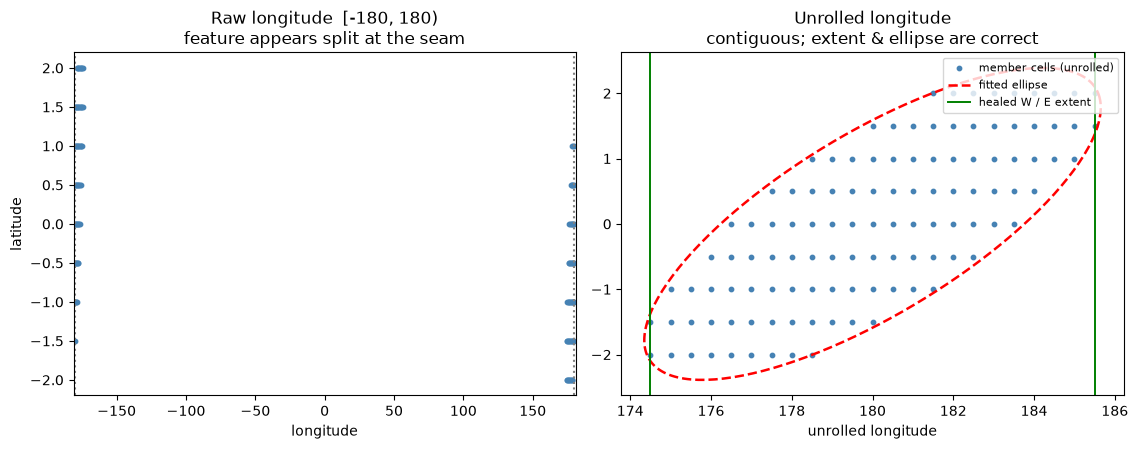

In [4]:
u = stats._unwrap_lons(f.lons)          # unrolled longitudes (may exceed +180)
lon0_u = float(u.mean())
lat0 = float(f.lats.mean())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.6))

axL.scatter(f.lons, f.lats, s=10, c="steelblue")
axL.axvline(180, ls=":", c="grey"); axL.axvline(-180, ls=":", c="grey")
axL.set_xlim(-181, 181)
axL.set_title("Raw longitude  [-180, 180)\nfeature appears split at the seam")
axL.set_xlabel("longitude"); axL.set_ylabel("latitude")

axR.scatter(u, f.lats, s=10, c="steelblue", label="member cells (unrolled)")
elon, elat = fitted_ellipse_lonlat(f, lat0, lon0_u)
axR.plot(elon, elat, "r--", lw=1.8, label="fitted ellipse")
axR.axvline(u.min(), c="green", lw=1.4); axR.axvline(u.max(), c="green", lw=1.4,
            label="healed W / E extent")
axR.set_title("Unrolled longitude\ncontiguous; extent & ellipse are correct")
axR.set_xlabel("unrolled longitude"); axR.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()

## Shape is invariant to where the seam falls

The clincher: build the *same* feature far from the dateline (centred on 0&deg;) and confirm every shape/extent statistic matches the straddling one to floating-point precision.

In [5]:
lon_away = lon_plot - 180.0                       # -12 .. 12, no wrapping needed
lats2d_a, lona2d = np.meshgrid(lat, lon_away, indexing="ij")
field_a = np.zeros_like(lats2d_a)
add_ellipse(field_a, lats2d_a, lona2d, clat=0.0, clon=0.0, a_deg=6.0, b_deg=1.5,
            angle_deg=20.0, val=5.0)
fa = extract_features(field_a, lats2d_a, lona2d, cfg, source="mem",
                      area=np.ones_like(field_a))[0]

for name, fn in [("lon_extent", stats.lon_extent), ("lat_extent", stats.lat_extent),
                 ("eccentricity", stats.eccentricity), ("elongation", stats.elongation),
                 ("major_axis_km", stats.major_axis_km), ("orientation_deg", stats.orientation_deg)]:
    a, b = fn(f), fn(fa)
    assert abs(a - b) < 1e-9, name
    print(f"{name:16s} straddling={a:10.4f}   away={b:10.4f}   match")

print("\nAll seam-invariance checks passed.")

lon_extent       straddling=   11.0000   away=   11.0000   match
lat_extent       straddling=    4.0000   away=    4.0000   match
eccentricity     straddling=    0.9672   away=    0.9672   match
elongation       straddling=    3.9381   away=    3.9381   match
major_axis_km    straddling= 1322.5300   away= 1322.5300   match
orientation_deg  straddling=   18.7507   away=   18.7507   match

All seam-invariance checks passed.


### Caveat

The seam healing covers the longitude **extents** and the geographic **ellipse fit**. `centroid_lon` and area-weighted stats are still naive at &plusmn;180&deg;, and detection joins a straddling feature only because the array columns are contiguous across the seam &mdash; there is no longitude wrapping in the connected-component labeling itself.